安装

In [8]:
#jieba wordcloud Pillow
! pip install wordcloud -i https://mirrors.aliyun.com/pypi/simple/

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


文本数据处理

In [2]:
import jieba
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#读取数据方法
train = pd.read_csv("./train.csv")
train.head()

,id,level_1,level_2,level_3,level_4,content,label
0,0,工业/危化品类（现场）—2016版,（二）电气安全,6、移动用电产品、电动工具及照明,1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用.",0
1,1,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,一般,1
2,2,工业/危化品类（现场）—2016版,（一）消防检查,2、防火检查,6、重点工种人员以及其他员工消防知识的掌握情况；,消防知识要加强,0
3,3,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,消防通道有货物摆放 清理不及时,0
4,4,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,4、常闭式防火门是否处于关闭状态，防火卷帘下是否堆放物品影响使用；,防火门打开状态,0


In [4]:
train.columns

Index(['id', 'level_1', 'level_2', 'level_3', 'level_4', 'content', 'label'], dtype='object')

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       12000 non-null  int64 
 1   level_1  12000 non-null  object
 2   level_2  12000 non-null  object
 3   level_3  12000 non-null  object
 4   level_4  12000 non-null  object
 5   content  11998 non-null  object
 6   label    12000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 656.4+ KB


In [6]:
#因为考虑有缺失值
train[["content","level_1","level_2","level_3","level_4"]]=train[["content","level_1","level_2","level_3","level_4"]].fillna("")

In [7]:
#数据的拼接
train["text"]=train["content"]+' '+train["level_1"]+' '+train["level_2"]+' '+train["level_3"]+' '+train["level_4"]

In [8]:
train['text']

0        使用移动手动电动工具,外接线绝缘皮破损,应停止使用. 工业/危化品类（现场）—2016版 （...
1        一般 工业/危化品类（现场）—2016版 （一）消防检查 1、防火巡查 3、消防设施、器材和...
2        消防知识要加强 工业/危化品类（现场）—2016版 （一）消防检查 2、防火检查 6、重点工...
3        消防通道有货物摆放 清理不及时 工业/危化品类（现场）—2016版 （一）消防检查 1、防火...
4        防火门打开状态 工业/危化品类（现场）—2016版 （一）消防检查 1、防火巡查 4、常闭式...
                               ...                        
11995    个别员工对消防栓的使用不熟练\r\n 商贸服务教文卫类（基础）—2016版 （四）安全教育培...
11996    化验室超净台照明电源线防护不足，且检测台金属架未安装漏电接地保护线。整改措施：更换照明灯为前...
11997    电箱、马达，没有防护罩，现在整改 工业/危化品类（现场）—2016版 （三）机械设备安全防护...
11998    D1部车间二楼配胶房排风扇未开启。 工业/危化品类（现场）—2016版 （四）作业环境 2、...
11999    已整改 纯办公场所（现场）—2016版 （一）消防安全 2、消防通道 1、疏散通道无占用、堵...
Name: text, Length: 12000, dtype: object

In [9]:
train['num_chars']=train['text'].map(len)

In [10]:
train['num_chars']

0        119
1         60
2         65
3         73
4         74
        ... 
11995     87
11996    123
11997     89
11998     63
11999     63
Name: num_chars, Length: 12000, dtype: int64

In [11]:
data=pd.Series(['低','中','高','中','低','高'])

In [12]:
s={'低':1,'中':2,'高':3}

In [13]:
dd=data.map(s)
dd

0    1
1    2
2    3
3    2
4    1
5    3
dtype: int64

In [14]:
train['num_chars'].describe()

count    12000.000000
mean        82.435917
std         22.658983
min         45.000000
25%         68.000000
50%         77.000000
75%         94.000000
max        360.000000
Name: num_chars, dtype: float64

文本数据处理

In [15]:
#去除标点负号和数字
# 正则
# https://stackoverflow.org.cn/regexdso/

In [16]:
import re
def clean_text(text):
    # 去除标点符号和数字 [\u4e00-\u9fa5]
    text=re.sub(r'[^\u4e00-\u9fa5]+','',text)
    return text

In [17]:
sample_text=train["text"][0]
sample_text

'使用移动手动电动工具,外接线绝缘皮破损,应停止使用. 工业/危化品类（现场）—2016版 （二）电气安全 6、移动用电产品、电动工具及照明 1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。'

In [18]:
clean_st=clean_text(sample_text)
clean_st

'使用移动手动电动工具外接线绝缘皮破损应停止使用工业危化品类现场版二电气安全移动用电产品电动工具及照明移动使用的用电产品和类电动工具的绝缘线必须采用三芯单相或四芯三相多股铜芯橡套软线'

In [19]:
#去除空格
text="2016版 电气安全 移动用电产品"
''.join(text.split())

'2016版电气安全移动用电产品'

#删除冗余字符
- \u200b: 零宽空格（Zero Width Space），常用于隐形排版。    
- \ufeff: Unicode 文件的字节顺序标记（BOM），可能意外出现在文本中。    
- \xa0: 非断空格（No-Break Space），类似普通空格，但不允许自动换行。

In [20]:
sa_text="你好\u200b北京!\ufeff 现在是\xa0晚上8点"
print(sa_text)
# repr 显示不可见的字符
print(repr(sa_text))

你好​北京!﻿ 现在是 晚上8点
'你好\u200b北京!\ufeff 现在是\xa0晚上8点'


In [21]:
#删除重复符号的数据
data="这是一个测试文本......你觉得呢？？？太棒了！！！不对。。。"
#替换句号为单个句号
data_clean1=re.sub(r'[.。]{2,}','。',data)
data_clean1

'这是一个测试文本。你觉得呢？？？太棒了！！！不对。'

In [22]:
data_clean2=re.sub(r'[!！]{2,}','！',data)
data_clean2

'这是一个测试文本......你觉得呢？？？太棒了！不对。。。'

In [23]:
data_clean3=re.sub(r'[?？]{2,}','?',data)
data_clean3

'这是一个测试文本......你觉得呢?太棒了！！！不对。。。'

In [24]:
import re
def clean_text(text):
    """
    清洗文本数据
    """
    #1.移除 HTML标签
    text = re.sub(r'<[^>]+>','',text)

    #2.移除URL
    text = re.sub(r'https?://\S+|www\.\S+','',text)

    #3. 移除 E_mail
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b','',text)

    #4.移除电话号码
    text = re.sub(r'\b\d{10,}\b|(\d{3}[-.\s]?\d{3}[-.\s]?\d{4})','',text)

    #5. 移除括号中的内容(包括中英文括号)
    text = re.sub(r'\(.*?\)|（.*?）','',text)

    #6. 移除异常字符和冗余字符(如特殊符号，重复空格等)
    text = re.sub(r'[^\w\s]','',text) # 移除所有非字母数字的符号
    text = re.sub(r'\s+',' ',text).strip() #去除多余空格

    #7. 全角字符转半角字符
    text = ''.join([chr(ord(c) - 0xFEE0) if 0xFF01 <= ord(c) <= 0xFF5E else c for c in text])

    return text

In [25]:
#测试样列
sample_text = """
Hello！这是一个测试文本。(测试内容） 访问网站 https://example.com 或发邮件至 test@example.com。
拨打电话 123-456-7890 获取更多信息。<b>HTML标签</b>和各种异常字符#￥%需要清理。全角ＡＢＣ转半角。
"""
clean_dd=clean_text(sample_text)
clean_dd

'Hello这是一个测试文本测试内容 访问网站 或发邮件至 拨打电话 获取更多信息HTML标签和各种异常字符需要清理全角ABC转半角'

In [26]:
#繁体转为简体
sample_text = "這是一段測試文本，用來測試繁體字轉換為簡體字的效果。"

In [27]:
! pip install opencc-python-reimplemented


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from opencc import OpenCC
c=OpenCC("t2s")
s=c.convert(sample_text)
print(s)

这是一段测试文本，用来测试繁体字转换为简体字的效果。


文本分词

In [29]:
import jieba
text="我要来到北京清华大学"
# 精确模式 (cut 方法， 默认）：精准地切分句子，适合文本分析。
worlds=jieba.cut(text)
print("/".join(worlds))

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Administrator\AppData\Local\Temp\jieba.cache
Loading model cost 1.955 seconds.
Prefix dict has been built successfully.


我要/来到/北京/清华大学


In [30]:
train.head()

,id,level_1,level_2,level_3,level_4,content,label,text,num_chars
0,0,工业/危化品类（现场）—2016版,（二）电气安全,6、移动用电产品、电动工具及照明,1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用.",0,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用. 工业/危化品类（现场）—2016版 （...",119
1,1,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,一般,1,一般 工业/危化品类（现场）—2016版 （一）消防检查 1、防火巡查 3、消防设施、器材和...,60
2,2,工业/危化品类（现场）—2016版,（一）消防检查,2、防火检查,6、重点工种人员以及其他员工消防知识的掌握情况；,消防知识要加强,0,消防知识要加强 工业/危化品类（现场）—2016版 （一）消防检查 2、防火检查 6、重点工...,65
3,3,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,消防通道有货物摆放 清理不及时,0,消防通道有货物摆放 清理不及时 工业/危化品类（现场）—2016版 （一）消防检查 1、防火...,73
4,4,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,4、常闭式防火门是否处于关闭状态，防火卷帘下是否堆放物品影响使用；,防火门打开状态,0,防火门打开状态 工业/危化品类（现场）—2016版 （一）消防检查 1、防火巡查 4、常闭式...,74


In [31]:
train['text_words']=train["text"].apply(lambda x:[w for w in jieba.cut(x)])
train['text_words']

0        [使用, 移动, 手动, 电动工具, ,, 外, 接线, 绝缘, 皮, 破损, ,, 应, ...
1        [一般,  , 工业, /, 危化, 品类, （, 现场, ）, —, 2016, 版,  ...
2        [消防, 知识, 要, 加强,  , 工业, /, 危化, 品类, （, 现场, ）, —,...
3        [消防通道, 有, 货物, 摆放,  , 清理, 不, 及时,  , 工业, /, 危化, ...
4        [防火门, 打开, 状态,  , 工业, /, 危化, 品类, （, 现场, ）, —, 2...
                               ...                        
11995    [个别, 员工, 对, 消防栓, 的, 使用, 不, 熟练, \r\n,  , 商贸, 服务...
11996    [化验室, 超净, 台, 照明, 电源线, 防护, 不足, ，, 且, 检测, 台, 金属,...
11997    [电箱, 、, 马达, ，, 没有, 防护罩, ，, 现在, 整改,  , 工业, /, 危...
11998    [D1, 部, 车间, 二楼, 配胶, 房, 排风扇, 未, 开启, 。,  , 工业, /...
11999    [已, 整改,  , 纯, 办公, 场所, （, 现场, ）, —, 2016, 版,  ,...
Name: text_words, Length: 12000, dtype: object

# 关键词提取 # jieba 提供两个方法提取关键词： # - 基于 TF-IDF (jieba.analyse.extract_tags) # - 基于 TextRank (jieba.analyse.textrank)

In [32]:
import jieba.analyse

In [33]:
text="我爱自然语言处理，人工智能正在改变世界"
key1=jieba.analyse.extract_tags(text,topK=3,withWeight=False)
key1

['自然语言', '人工智能', '处理']

In [34]:
text="我爱自然语言处理，人工智能正在改变世界"
key2=jieba.analyse.textrank(text,topK=3,withWeight=False)
key2

['改变', '人工智能', '处理']

In [35]:
#词频统计
from collections import Counter
text = "自然语言处理是人工智能的重要分支,自然语言处理非常有趣。"
words=jieba.cut(text)
words_counts=Counter(words)
words_counts
for word,count in words_counts.most_common(5):
    print(word,count)

自然语言 2
处理 2
是 1
人工智能 1
的 1


In [36]:
all_words="".join([" ".join(words)for words in train['text_words']])

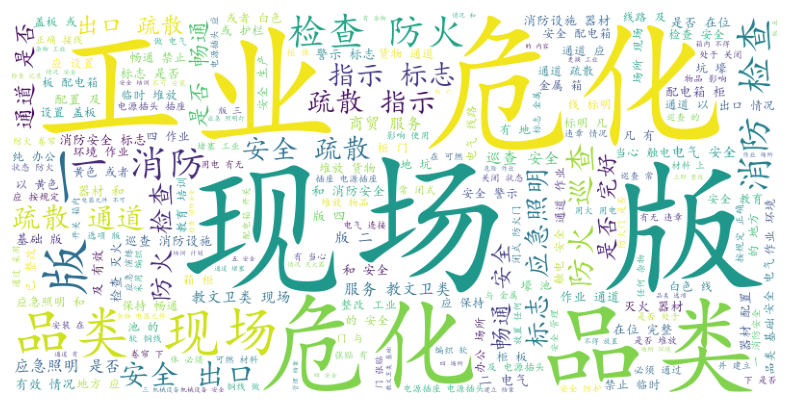

In [37]:
#生成词云图
import jieba
from wordcloud import WordCloud
import matplotlib.pyplot as plt
#生成词云
wordcloud = WordCloud(
    font_path="simkai.ttf", #字体文件路径(确保支持中文)
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

# 显示词云
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

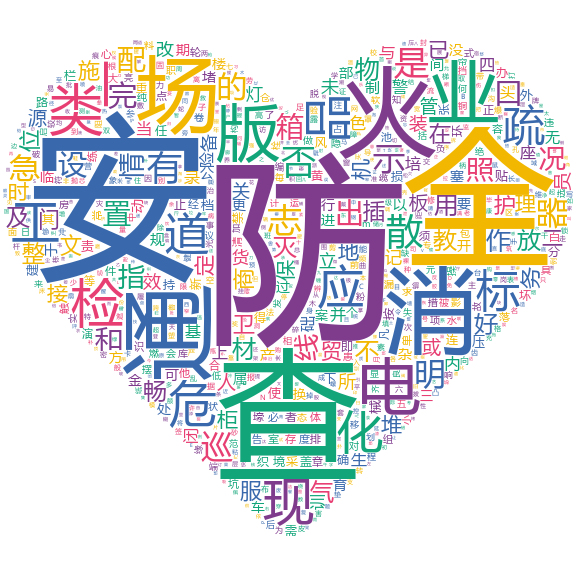

In [42]:
import stylecloud
from pathlib import Path
from IPython.display import Image # 用于在jupyter lab中显示本地图片

#绘制词云图
stylecloud.gen_stylecloud(
    text=' '.join(all_words),
    collocations=False,
    font_path=r'C:\Windows\Fonts\msyh.ttc',#2-1字体的path路径
    icon_name='fas fa-heart',
    size= 578,
    output_name='数据保存.png'
)
Image(filename='数据保存.png')

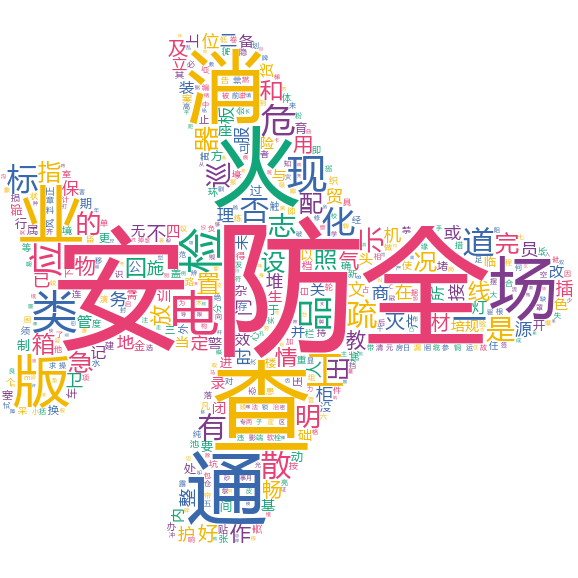

In [43]:
import stylecloud
from pathlib import Path
from IPython.display import Image # 用于在jupyter lab中显示本地图片

#绘制词云图
stylecloud.gen_stylecloud(
    text=' '.join(all_words),
    collocations=False,
    font_path=r'C:\Windows\Fonts\msyh.ttc',#2-1字体的Path路径，
    icon_name='fas fa-plane',
    size = 578,
    output_name='数据保存.png'
)
Image(filename='数据保存.png')

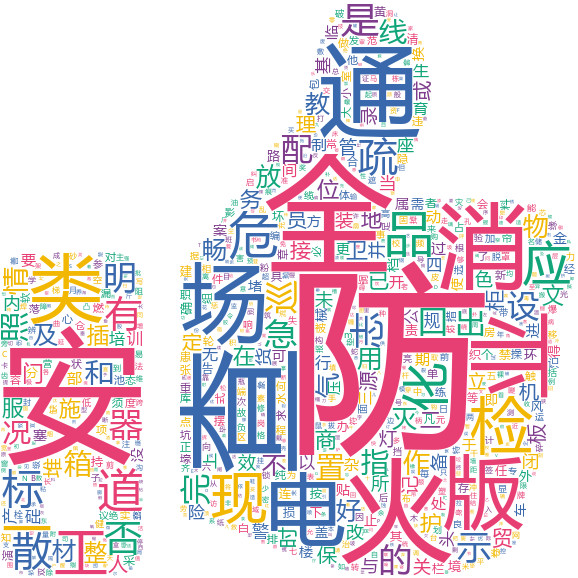

In [45]:
import stylecloud
from pathlib import Path
from IPython.display import Image # 用于在jupyter lab中显示本地图片

# 绘制词云图
stylecloud.gen_stylecloud(
    text=' '.join(all_words),
    collocations=False,
    font_path=r'‪C:\Windows\Fonts\msyh.ttc',#2-1字体的Path路径，
    icon_name='fas fa-thumbs-up',
    size= 578,
    output_name='数据保存.png'
)
Image(filename='数据保存.png')

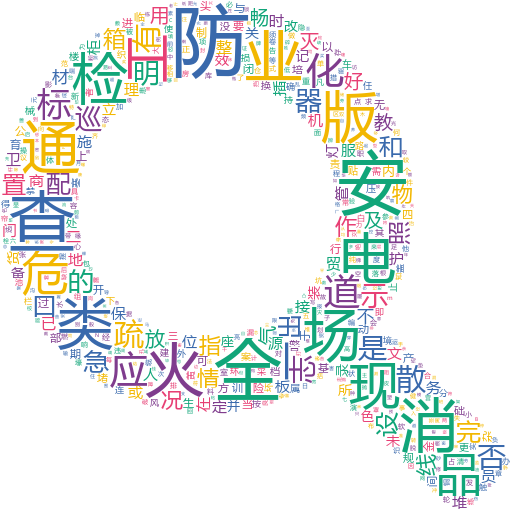

In [46]:
import stylecloud
from pathlib import Path
from IPython.display import Image #用于在jupyter lab中显示本地图片

#绘制词云图
stylecloud.gen_stylecloud(
    text=' '.join(all_words),
    collocations=False,
    font_path=r'‪C:\Windows\Fonts\msyh.ttc',#2-1字体的Path路径，
    icon_name='fas fa-search',
    output_name='数据保存.png'
)
Image(filename='数据保存.png')